#### Import

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from tqdm import tqdm
from functions_utils import *
from functions_data import *
from functions_optimize import *

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
S, R, P_RT, K, K0, M1, M2 = load_parameters(I, T, generation_data)
P_DA, P_PN = load_price_data()

✅ 총 10개 파일을 불러왔습니다: 1201.csv, 137.csv, 281.csv, 397.csv, 401.csv, 430.csv, 514.csv, 524.csv, 775.csv, 89.csv
📊 데이터 Shape: I=10, T=24, S=20
✅ 시뮬레이션 초기화 완료: S=20, Randomness='high', M1=768.00, M2=2463.00


#### Preliminaries

In [2]:
print("[Individual Participation Model optimization]")
x_ind, yp_ind, ym_ind, z_ind, zc_ind, zd_ind, obj_ind = optimize_individually_forall(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1)
print("-"*100)

print("[Holistic Aggregation Model optimization]")
x_hol, a_hol, yp_hol, ym_hol, z_hol, zc_hol, zd_hol, ep_hol, bp_hol, em_hol, bm_hol, d_hol, dp_hol, dm_hol, obj_hol = optimize_hol(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1, M2)
print("-"*100)

print("[Extracting target_i from Holistic Aggregation Model]")
x_extracted, ep_extracted, em_extracted, yp_extracted, ym_extracted, d_extracted, dp_extracted, dm_extracted, i_map_extracted = extracted_target(I, T, S, x_hol, ep_hol, em_hol, yp_hol, ym_hol, d_hol, dp_hol, dm_hol)
print("-"*100)

print("[Holistic Aggregation Model optimization without target_i]")
x_without, ep_without, em_without, yp_without, ym_without, d_without, dp_without, dm_without, i_map_without = optimize_without_loop(R, K, K0, P_DA, P_RT, P_PN, I, T, S)
print("-"*100)

[Individual Participation Model optimization]


Optimizing individually for each target_i:   0%|          | 0/10 [00:00<?, ?it/s]

Set parameter Username
Set parameter LicenseID to value 2681721
Academic license - for non-commercial use only - expires 2026-06-24
Set parameter MIPGap to value 1e-07


Optimizing individually for each target_i:  10%|█         | 1/10 [00:00<00:01,  7.96it/s]

Optimal solution found for target_i=0! Objective value: 216712.16374347793
Set parameter MIPGap to value 1e-07


...

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER:  90%|█████████ | 9/10 [04:40<00:33, 33.55s/it]

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER: 100%|██████████| 10/10 [05:21<00:00, 32.20s/it]

----------------------------------------------------------------------------------------------------


#### Price Functions

In [3]:
rdc, rsc, rho_plus, rho_minus, total_demand_without, total_supply_without = compute_price_functions(yp_without, ym_without, dp_without, dm_without, i_map_without, P_RT, P_PN, T, S, I)
# rdc, rsc, rho_plus, rho_minus, total_demand_without, total_supply_without = compute_price_functions(yp_extracted, ym_extracted, dp_extracted, dm_extracted, i_map_extracted, P_RT, P_PN, T, S, I)

In [4]:
target_i, t, s = 1, 10, 0
ap, bp = rho_plus[target_i, t, s, :]
am, bm = rho_minus[target_i, t, s, :]
print(f"ρ⁺(d) = {ap:.2f} + {bp:.2f}·d")
print(f"ρ⁻(d) = {am:.2f} + {bm:.2f}·d")

ρ⁺(d) = 137.79 + -26.30·d
ρ⁻(d) = 137.79 + 26.30·d


In [5]:
RP, RM, BP, BM = transform_step(rho_plus, rho_minus, total_demand_without, total_supply_without, step_width_multiplier=1)

In [6]:
print(yp_without[target_i][:, t, s])
print(BP[target_i, t, s])
print(RP[target_i, t, s])

print(ym_without[target_i][:, t, s])
print(BM[target_i, t, s])
print(RM[target_i, t, s])

[0. 0. 0. 2. 0. 0. 2. 0. 0.]
4
[[  0.         137.78679334]
 [  0.5        124.63886668]
 [  1.5         98.34301335]
 [  2.5         72.04716002]
 [  3.5         45.75130669]]
[0. 0. 0. 0. 0. 0. 0. 4. 0.]
4
[[  0.         137.78679334]
 [  0.5        150.93472001]
 [  1.5        177.23057334]
 [  2.5        203.52642666]
 [  3.5        229.82227999]]


#### Stepwise Model

In [7]:
x_part, yp_part, ym_part, z_part, zc_part, zd_part, dp_part, dm_part, up_part, um_part, wp_part, wm_part, obj_part, RP_CLEARED, RM_CLEARED = stepwise_optimize_forall(I, T, S, R, K, K0, P_DA, P_RT, P_PN, RP, RM, BP, BM, total_demand_without, total_supply_without, M1)

Optimizing Stepwise for each target_i: 100%|██████████| 10/10 [01:48<00:00, 10.80s/it]


Best Case Scenario

In [25]:
def calculate_total_profit_best_case(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I):
    BEST_CASE_PROFIT = np.zeros(I)
    
    for target_i in range(I):
        profit = 0
        for t in range(T):
            for s in range(S):
                basic_profit = (x_part[target_i][t] * P_DA[t] + 
                              yp_part[target_i][t, s] * P_RT[t, s] - 
                              ym_part[target_i][t, s] * P_PN[t])

                # dp_others = sum(dp_part[i][t, s] for i in range(I) if i != target_i)
                # dm_others = sum(dm_part[i][t, s] for i in range(I) if i != target_i)

                dp_others = sum(dp_extracted[target_i][j, t, s] for j in range(I-1))
                dm_others = sum(dm_extracted[target_i][j, t, s] for j in range(I-1))
                
                sold_internal = min(dp_part[target_i][t, s], dm_others)
                sold_rt = max(0, dp_part[target_i][t, s] - dm_others)
                
                bought_internal = min(dm_part[target_i][t, s], dp_others)
                bought_penalty = max(0, dm_part[target_i][t, s] - dp_others)
                
                internal_profit = (RP_CLEARED[target_i, t, s] * sold_internal + 
                                 P_RT[t, s] * sold_rt - 
                                 RM_CLEARED[target_i, t, s] * bought_internal - 
                                 P_PN[t] * bought_penalty)
                
                profit += (basic_profit + internal_profit) / S
        
        BEST_CASE_PROFIT[target_i] = profit
    
    return BEST_CASE_PROFIT

In [26]:
BEST_CASE_PROFIT = calculate_total_profit_best_case(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
print(BEST_CASE_PROFIT)

[242905.95930059 377262.90665313 224972.25064654  76143.12999714
 415740.02628123 119185.2357624  109597.11830667 460231.63871374
 156804.64910818 202995.87933364]


Worst Case Scenario

In [32]:
def calculate_total_profit_worst_case(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I):
    WORST_CASE_PROFIT = np.zeros(I)
    
    for target_i in range(I):
        profit = 0
        for t in range(T):
            for s in range(S):
                basic_profit = (x_part[target_i][t] * P_DA[t] + 
                              yp_part[target_i][t, s] * P_RT[t, s] - 
                              ym_part[target_i][t, s] * P_PN[t])

                # dp_others = sum(dp_part[i][t, s] for i in range(I) if i != target_i)
                # dm_others = sum(dm_part[i][t, s] for i in range(I) if i != target_i)

                dp_others = sum(dp_extracted[target_i][j, t, s] for j in range(I-1))
                dm_others = sum(dm_extracted[target_i][j, t, s] for j in range(I-1))
                
                net_others_demand = max(0, dm_others - dp_others)  # others' net demand
                net_others_supply = max(0, dp_others - dm_others)  # others' net supply
                
                sold_internal = min(dp_part[target_i][t, s], net_others_demand)
                sold_rt = max(0, dp_part[target_i][t, s] - net_others_demand)
                
                bought_internal = min(dm_part[target_i][t, s], net_others_supply)
                bought_penalty = max(0, dm_part[target_i][t, s] - net_others_supply)
                
                internal_profit = (RP_CLEARED[target_i, t, s] * sold_internal + 
                                 P_RT[t, s] * sold_rt - 
                                 RM_CLEARED[target_i, t, s] * bought_internal - 
                                 P_PN[t] * bought_penalty)
                
                profit += (basic_profit + internal_profit) / S
        
        WORST_CASE_PROFIT[target_i] = profit
    
    return WORST_CASE_PROFIT

In [33]:
WORST_CASE_PROFIT = calculate_total_profit_worst_case(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
print(WORST_CASE_PROFIT)

[241263.19880562 374999.02864763 222771.12924891  75346.38441809
 414114.54432949 118750.80644145 108597.86760415 457699.10496106
 156164.17292821 200860.66036222]


가상가격 제외

In [45]:
def calculate_total_profit_no_virtual_price(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I):
    NO_VIRTUAL_PRICE_PROFIT = np.zeros(I)
    
    for target_i in range(I):
        profit = 0
        for t in range(T):
            for s in range(S):
                basic_profit = (x_part[target_i][t] * P_DA[t] + 
                              (yp_part[target_i][t, s]+dp_part[target_i][t, s]) * P_RT[t, s] - 
                              (ym_part[target_i][t, s]+dm_part[target_i][t, s]) * P_PN[t])

                profit += basic_profit / S
        
        NO_VIRTUAL_PRICE_PROFIT[target_i] = profit
    
    return NO_VIRTUAL_PRICE_PROFIT

In [46]:
NO_VIRTUAL_PRICE_PROFIT = calculate_total_profit_no_virtual_price(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
print(NO_VIRTUAL_PRICE_PROFIT)

[238624.36718166 371753.25484068 220641.72942878  75138.81316545
 410664.08740354 118413.43614585 107947.30269719 454872.20815428
 155836.70192998 198633.43962437]


#### Results

In [8]:
target_i = 2

header = (
    f"{'s':>2} {'t':>2} | "
    f"{'R':>8} {'x':>8} {'y+':>8} {'y-':>8} "
    f"{'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n"
    + "-" * 90
)
print(header)

for s, t in product(range(0,1), range(T)):
    print(
        f"{s:>2} {t:>2} | "
        f"{R[target_i, t, s]:>8.2f} {x_part[target_i][t]:>8.2f} {yp_part[target_i][t, s]:>8.2f} {ym_part[target_i][t, s]:>8.2f} "
        f"{dp_part[target_i][t, s]:>8.2f} {dm_part[target_i][t, s]:>8.2f} {zc_part[target_i][t, s]:>8.2f} {zd_part[target_i][t, s]:>8.2f} {z_part[target_i][t, s]:>8.2f}"
    )

 s  t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0  0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  2 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  3 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  4 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  5 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  6 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  7 |     5.00     0.00     0.00     0.00     0.00     0.00     5.00     0.00     0.00
 0  8 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     5.00
 0  9 |    10.00   

In [9]:
df_rho_cleared = pd.DataFrame([
    {
        "i": target_i,
        "t": t,
        "s": s,
        "..": "||", 
        "RT": P_RT[t, s],
        "yp": yp_part[target_i][t, s],
        "rho_plus": RP_CLEARED[target_i, t, s],
        "dp": dp_part[target_i][t, s],
        ".": "|", 
        "PN": P_PN[t],
        "ym": ym_part[target_i][t, s],
        "rho_minus": RM_CLEARED[target_i, t, s],
        "dm": dm_part[target_i][t, s]
    }
    for s in range(0, 1)
    for t in range(T)
])

pd.DataFrame(df_rho_cleared)

,i,t,s,..,RT,yp,rho_plus,dp,.,PN,ym,rho_minus,dm
0,2,0,0,||,52.112,0.000,-10000000000.000,0.000,|,148.649,0.000,10000000000.000,0.000
1,2,1,0,||,104.434,0.000,-10000000000.000,0.000,|,129.714,0.000,10000000000.000,0.000
2,2,2,0,||,55.635,0.000,-10000000000.000,0.000,|,119.828,0.000,10000000000.000,0.000
3,2,3,0,||,78.375,0.000,-10000000000.000,0.000,|,115.557,0.000,10000000000.000,0.000
4,2,4,0,||,71.220,0.000,-10000000000.000,0.000,|,115.226,0.000,10000000000.000,0.000
5,2,5,0,||,76.733,0.000,-10000000000.000,0.000,|,119.710,0.000,10000000000.000,0.000
6,2,6,0,||,72.227,0.000,-10000000000.000,0.000,|,130.299,0.000,10000000000.000,0.000
7,2,7,0,||,94.466,0.000,-10000000000.000,0.000,|,142.526,0.000,10000000000.000,0.000
8,2,8,0,||,77.202,0.000,-10000000000.000,0.000,|,170.099,0.000,10000000000.000,0.000
9,2,9,0,||,74.498,0.000,129.279,0.000,|,184.061,0.000,129.279,0.000


In [10]:
target_i = 0
compare_onestep(a_hol, bp_hol, bm_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, x_without, ep_without, em_without, dp_without, dm_without, T, target_i)
print()
compare_onestep_detailed(a_hol, bp_hol, bm_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, x_without, ep_without, em_without, dp_without, dm_without, T, target_i)

=== [시나리오 평균] set 모델 vs (PWL + without) 결과 비교 (target_i=0) ===

 t |      a_opt      x_sum ||     bp_opt     yp_avg ||     bm_opt     ym_avg ||     dp_opt     dp_avg ||     dm_opt     dm_avg
-----------------------------------------------------------------------------------------------------------------------------
 0 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 1 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 2 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 3 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 4 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 5 |      0.000      0.000 ||      0.050      0.

In [11]:
compare_allstep(a_hol, bp_hol, bm_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, T)

=== [시나리오 평균] set 모델 vs 전체 PWL 결과 비교 ===

 t |      a_opt  x_pwl_sum ||     bp_opt     yp_avg ||     bm_opt     ym_avg ||     dp_opt     dp_avg ||     dm_opt     dm_avg
-----------------------------------------------------------------------------------------------------------------------------
 0 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 1 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 2 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 3 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 4 |      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000 ||      0.000      0.000
 5 |      0.000      0.000 ||      0.050      0.050 ||      0.000     

=== Individual Participation vs Stepwise Model 비교 (target_i=0) ===
 t |    x_ind   x_step ||   yp_ind  yp_step  dp_step ||   ym_ind  ym_step  dm_step
--------------------------------------------------------------------------------
 0 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 1 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 2 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 3 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 4 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 5 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 6 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 7 |    0.000    0.000 ||    0.000    0.000    0.000 ||    0.000    0.000    0.000
 8 |    0.000    0.000 ||    2.500    0.925    0.000 ||    0.000    0.000    0.000
 9 |    0.000    0.000

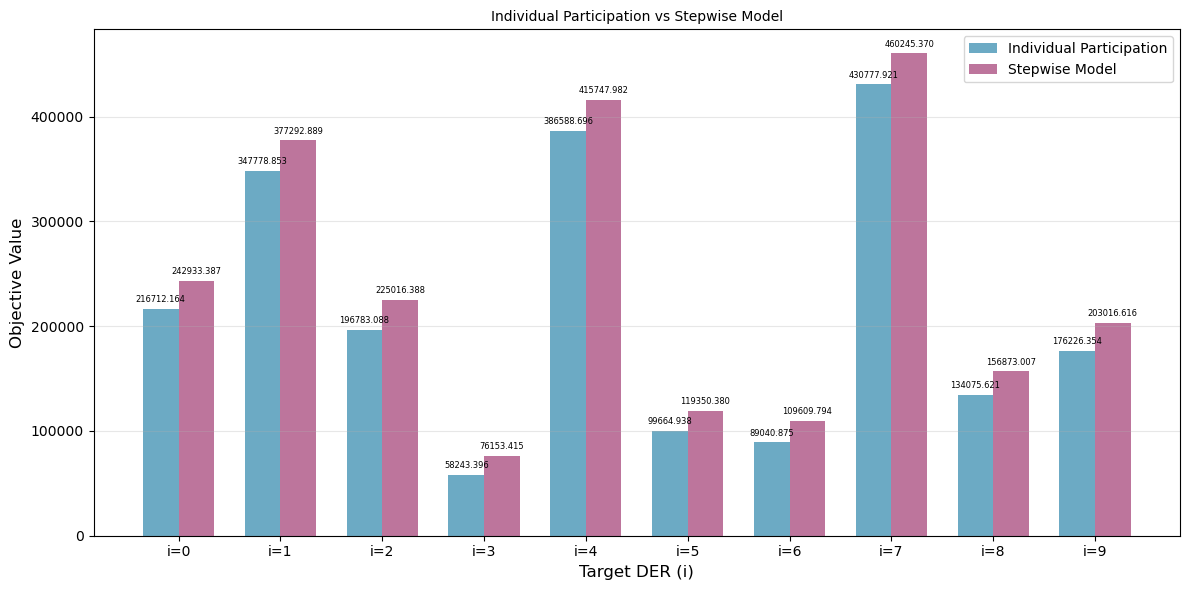

In [12]:
for target_i in range(I):
    print(f"=== Individual Participation vs Stepwise Model 비교 (target_i={target_i}) ===")
    print(f"{'t':>2} | {'x_ind':>8} {'x_step':>8} || {'yp_ind':>8} {'yp_step':>8} {'dp_step':>8} || {'ym_ind':>8} {'ym_step':>8} {'dm_step':>8}")
    print("-" * 80)

    for t in range(T):
        x_ind_avg = x_ind[target_i][t]
        yp_ind_avg = np.mean(yp_ind[target_i][t, :])
        ym_ind_avg = np.mean(ym_ind[target_i][t, :])
        
        x_step = x_part[target_i][t]
        yp_step = np.mean(yp_part[target_i][t, :])
        ym_step = np.mean(ym_part[target_i][t, :])
        dp_step = np.mean(dp_part[target_i][t, :])
        dm_step = np.mean(dm_part[target_i][t, :])
        
        print(f"{t:>2} | {x_ind_avg:>8.3f} {x_step:>8.3f} || {yp_ind_avg:>8.3f} {yp_step:>8.3f} {dp_step:>8.3f} || {ym_ind_avg:>8.3f} {ym_step:>8.3f} {dm_step:>8.3f}")

    print(f"\n=== Objective Value 비교 ===")
    print(f"Individual Participation: {obj_ind[target_i]:.3f}")
    print(f"Stepwise Model: {obj_part[target_i]:.3f}")

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(I)
width = 0.35

ind_values = [obj_ind[i] for i in range(I)]
step_values = [obj_part[i] for i in range(I)]

bars1 = ax.bar(x_pos - width/2, ind_values, width, label='Individual Participation', color='#2E86AB', alpha=0.7)
bars2 = ax.bar(x_pos + width/2, step_values, width, label='Stepwise Model', color='#A23B72', alpha=0.7)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(max(ind_values), max(step_values))*0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=6)

ax.set_xlabel('Target DER (i)', fontsize=12)
ax.set_ylabel('Objective Value', fontsize=12)
ax.set_title('Individual Participation vs Stepwise Model', fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'i={i}' for i in range(I)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()